<a href="https://colab.research.google.com/github/DawDab/multimodal-anomaly/blob/master/phi4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install anomalib[full]
!pip install flash_attn==2.7.4.post1 torch==2.6.0 transformers==4.48.2 accelerate==1.3.0 soundfile==0.13.1 pillow==11.1.0 scipy==1.15.2 torchvision==0.21.0 backoff==2.2.1 peft==0.13.2
!pip install backoff

  Using cached flash_attn-2.7.4.post1.tar.gz (6.0 MB)
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 132.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.6/336.6 kB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.7/320.7 kB 35.9 MB/s eta 0:00:00
  Created wheel for flash_attn: filename=flash_attn-2.7.4.post1-cp311-cp311-linux_x86_64.whl size=187831595 sha256=58853b28a5a926cae14402bfd8d4d93a45ebf8f9e79533f37ab09d0d77a99c05
  Stored in directory: /root/.cache/pip/wheels/3d/88/d8/284b89f56af7d5bf366b10d6b8e251ac8a7c7bf3f04203fb4f
Successfully built flash_attn
  Attempting uninstall: scipy
    Found existing installation: scipy 1.14.1
    Uninstalling scipy-1.14.1:
  

In [1]:
from anomalib.data import MVTec
root_directory = "./datasets/MVTec"
datamodule = MVTec(root=root_directory)
datamodule.prepare_data()

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

<ipython-input-1-8ac57c8ada56>:3: DeprecationWarning: MVTec is deprecated and will be removed in a future version. Please use MVTecAD instead.
  datamodule = MVTec(root=root_directory)


In [2]:
import requests
import torch
import os
import io
from PIL import Image
from transformers import AutoModelForCausalLM, AutoProcessor, GenerationConfig
from pathlib import Path
import random

model_path = "microsoft/Phi-4-multimodal-instruct"

processor = AutoProcessor.from_pretrained(model_path, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    model_path,
    device_map="cuda",
    torch_dtype="auto",
    trust_remote_code=True,
    _attn_implementation='flash_attention_2',
    # _attn_implementation='eager',
).cuda()

generation_config = GenerationConfig.from_pretrained(model_path)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/models/auto/image_processing_auto.py:590: FutureWarning: The image_processor_class argument is deprecated and will be removed in v4.42. Please use `slow_image_processor_class`, or `fast_image_processor_class` instead
  warnings.warn(
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow 

vision_siglip_navit.py:   0%|          | 0.00/78.2k [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Phi-4-multimodal-instruct:
- vision_siglip_navit.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/microsoft/Phi-4-multimodal-instruct:
- speech_conformer_encoder.py
- vision_siglip_navit.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors.index.json:   0%|          | 0.00/240k [00:00<?, ?B/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/4.95G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

/root/.cache/huggingface/modules/transformers_modules/microsoft/Phi-4-multimodal-instruct/49434512b7724a18ba0631ca296ed4dfbd9e29c9/speech_conformer_encoder.py:2774: FutureWarning: Please specify CheckpointImpl.NO_REENTRANT as CheckpointImpl.REENTRANT will soon be removed as the default and eventually deprecated.
  lambda i: encoder_checkpoint_wrapper(


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


--- MVTEC DATASET PROCESSING ---
Available categories: ['hazelnut', 'toothbrush', 'screw', 'carpet', 'tile', 'cable', 'bottle', 'wood', 'grid', 'transistor', 'metal_nut', 'pill', 'zipper', 'leather', 'capsule']
Selected category: bottle
Available defect types: ['broken_large', 'good', 'contamination', 'broken_small']

Processing normal image: datasets/MVTec/bottle/train/good/148.png


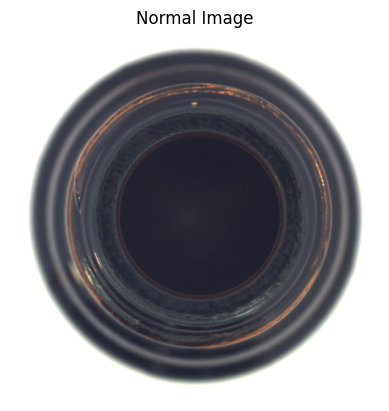

>>> Response for normal image:
The image shows a clear glass bottle with a dark liquid inside. There are no visible defects or anomalies in the bottle or the liquid.

--- Processing Defect Type: broken_large ---

Processing anomalous (broken_large) image: datasets/MVTec/bottle/test/broken_large/004.png


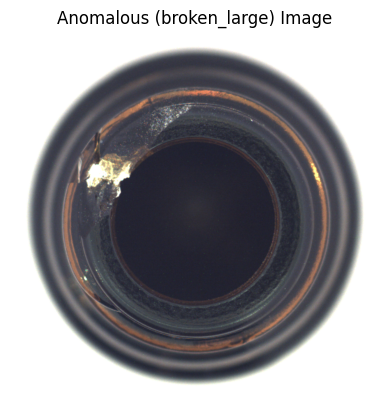

>>> Response for anomalous (broken_large) image:
The image shows a bottle with a broken seal, which is an anomaly indicating a defect.

--- Processing Defect Type: contamination ---

Processing anomalous (contamination) image: datasets/MVTec/bottle/test/contamination/015.png


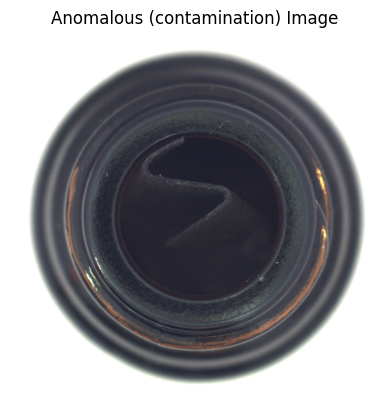

>>> Response for anomalous (contamination) image:
The image shows a clear liquid with a swirl pattern, which could be a defect if it indicates contamination or improper mixing. However, without additional context, it's not possible to definitively determine if it's a defect.

--- Processing Defect Type: broken_small ---

Processing anomalous (broken_small) image: datasets/MVTec/bottle/test/broken_small/013.png


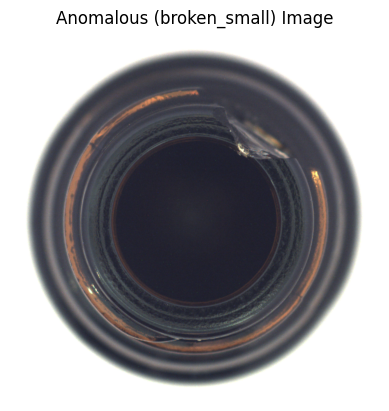

>>> Response for anomalous (broken_small) image:
The image shows a clear liquid in a bottle with a smooth surface, no visible defects or anomalies.

--- END OF PROCESSING ---


In [7]:
import os
import random
from pathlib import Path
from PIL import Image
import torch
import matplotlib.pyplot as plt

def load_mvtec_images(category, subset="good", num_images=1):
    """Load images from MVTec dataset."""
    mvtec_dir = root_directory  # Ensure this is defined
    category_dir = os.path.join(mvtec_dir, category)

    if subset == "good":
        image_dir = os.path.join(category_dir, "train", "good")
    else:
        image_dir = os.path.join(category_dir, "test", subset)

    if not os.path.exists(image_dir):
        print(f"Directory not found: {image_dir}")
        return []

    image_paths = list(Path(image_dir).glob("*.png")) + list(Path(image_dir).glob("*.jpg"))
    if not image_paths:
        print(f"No images found in {image_dir}")
        return []

    images = []
    for img_path in random.sample(image_paths, min(num_images, len(image_paths))):
        images.append({"image": Image.open(img_path), "path": str(img_path)})

    return images

# --- PROCESS MVTec Dataset ---
print("\n--- MVTEC DATASET PROCESSING ---")

mvtec_dir = root_directory
available_categories = [d for d in os.listdir(mvtec_dir) if os.path.isdir(os.path.join(mvtec_dir, d))]
print(f"Available categories: {available_categories}")

category = "bottle"
print(f"Selected category: {category}")

defect_dir = os.path.join(mvtec_dir, category, "test")
defect_types = [d for d in os.listdir(defect_dir) if os.path.isdir(os.path.join(defect_dir, d))]

if not defect_types:
    print("No defect types found!")
else:
    print(f"Available defect types: {defect_types}")

    normal_images = load_mvtec_images(category, "good")

    def process_and_display(image_data, label):
        """Process image and display results."""
        if not image_data:
            print(f"No {label} images available.")
            return

        image = image_data[0]["image"]
        path = image_data[0]["path"]
        print(f"\nProcessing {label} image: {path}")

        # Display Image
        plt.imshow(image)
        plt.title(f"{label.capitalize()} Image")
        plt.axis("off")
        plt.show()

        # Model Processing
        prompt = f'{user_prompt}<|image_1|>Analyze this image and determine if there are any defects or anomalies.{prompt_suffix}{assistant_prompt}'
        inputs = processor(text=prompt, images=image, return_tensors='pt').to('cuda:0')

        generate_ids = model.generate(**inputs, max_new_tokens=1000, generation_config=generation_config)
        generate_ids = generate_ids[:, inputs['input_ids'].shape[1]:]
        response = processor.batch_decode(generate_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0]

        print(f'>>> Response for {label} image:\n{response}')

    # Process Normal Image
    process_and_display(normal_images, "normal")

    # Process Each Defect Type
    for defect in defect_types:
        if defect == "good":
            continue  # Skip good images in test set

        print(f"\n--- Processing Defect Type: {defect} ---")
        defect_images = load_mvtec_images(category, defect)
        process_and_display(defect_images, f"anomalous ({defect})")

print("\n--- END OF PROCESSING ---")
